In [38]:
from os import listdir, makedirs
from os.path import isfile, isdir, join

import numpy as np
import pandas as pd

def get_flare_dataframe(file_path):
    """Reads the flare dataframe given in flare file path, downloaded using our script"""
    df = pd.read_csv(file_path, delimiter=',',
                     parse_dates=['start_time', 'end_time', 'peak_time', 'peak_time_aia', 'peak_time_goes'])
    new_columns = df.columns.values
    new_columns[0] = 'flare_id'
    df.columns = new_columns
    df = df.set_index('flare_id')

    # return fix_noaa_ar_numbers( pd.read_csv(file_path, delimiter='\t', parse_dates=True) )
    df = fix_end_times(fix_peak_times(fix_flare_locations(fix_noaa_ar_numbers(df))))
    # df = df[ df['goes_class'] > 'C9.9' ]
    return df

def fix_peak_times(df):
    """ Gets the flare dataframe and consolidates the peaktimes from aia and goes using the following strategy
        if the is a valid peak time from goes, it uses that. If not it uses the aia one"""

    # for each null (nan) peak time, get the peak time from goes
    df.loc[pd.isnull(df['peak_time']), 'peak_time'] = df.loc[pd.isnull(df['peak_time']), 'peak_time_goes']
    
    # for each null (nan) peak time, get the peak time from aia
    df.loc[pd.isnull(df['peak_time']), 'peak_time'] = df.loc[pd.isnull(df['peak_time']), 'peak_time_aia']

    return df

def fix_end_times(df):
    """ Gets the flare dataframe and consolidates the end times from aia and goes using the following strategy
        if the is a valid peak time from goes, it uses that. If not it uses the aia one"""

    # for each null (nan) peak time, get the peak time from goes
    df.loc[pd.isnull(df['end_time']), 'end_time'] = df.loc[pd.isnull(df['end_time']), 'end_time_y']
    
    # for each null (nan) peak time, get the peak time from aia
    df.loc[pd.isnull(df['end_time']), 'end_time'] = df.loc[pd.isnull(df['end_time']), 'end_time_x']


    return df

def fix_noaa_ar_numbers(df):
    """ Gets the flare dataframe and consolidates the noaa ar numbers from aia and goes using the following strategy
        if the is a valid goes active region, that is not 0, it uses that. If not it uses a valid aia number"""

    # set goes noaa numbers as primary source
    df['noaa_active_region'] = df['noaa_active_region_goes']
    # if noaa ar no from goes is zero, set it to NaN
    df.loc[df['noaa_active_region'] == 0, 'noaa_active_region'] = np.nan

    # for each null (nan) noaa ar number, get the ar number from aia
    df.loc[pd.isnull(df['noaa_active_region']), 'noaa_active_region'] = \
        df.loc[pd.isnull(df['noaa_active_region']), 'noaa_active_region_aia']
    # for each noaa ar number that is still zero, set it to nan
    df.loc[df['noaa_active_region'] == 0, 'noaa_active_region'] = np.nan

    # print len(df['noaa_active_region'].unique())
    return df

def fix_flare_locations(df):
    """ Gets the flare dataframe and consolidates the flare locations from aia and goes using the following strategy
        if there is a valid aia location, that is not NaN, it uses that. If not it uses the goes location if valid"""

    # set aia location as primary source
    df['fl_location'] = df['aia_location']
    # if noaa ar no from goes is zero, set it to goes location
    df.loc[pd.isnull(df['fl_location']), 'fl_location'] = df.loc[pd.isnull(df['fl_location']), 'goes_location']

    # for each goes location that is still invalid --(0, 0), set it to nan
    df.loc[df['fl_location'] == '(0, 0)', 'fl_location'] = np.nan

    # create two new columns fl_lat and fl_lon for latitude and longitude
    df = df.reindex(columns=np.append(df.columns.values, ['fl_lat', 'fl_lon']))
    # extract the locations from either aia or goes location strings
    df = df.apply(reformat_locations, axis=1)

    # print df.to_csv('flares_flares.csv')
    return df

def reformat_locations(row):
    gloc = row['fl_location']
    # print pd.isnull(gloc),gloc
    if pd.isnull(gloc):
        row['fl_lon'] = np.nan
        row['fl_lat'] = np.nan
    elif gloc.startswith('POINT'):
        row['fl_lat'] = float(gloc.strip('POINT(').strip(')').split(' ')[0])
        row['fl_lon'] = float(gloc.strip('POINT(').strip(')').split(' ')[1])
    elif gloc.startswith('('):
        row['fl_lat'] = float(gloc.strip('(').strip(')').split(', ')[0])
        row['fl_lon'] = float(gloc.strip('(').strip(')').split(', ')[1])
    else:
        row['fl_lon'] = np.nan
        row['fl_lat'] = np.nan
    return row

In [39]:

flare_file_path = '/home/baydin2/workspace/flarepredictiondata/flare_reading/output/joined_flares.csv'
fdf = get_flare_dataframe(flare_file_path)

aia_fl_file_path = './aiaFlares.txt'
aia_fl = get_aia_flare_dataframe(aia_fl_file_path)


In [57]:
goes_only_mx = fdf [fdf['id_aia'].isna() & (fdf['goes_class'] >= 'M')]
print goes_only_mx.shape[0]

aia_only_mx = fdf [fdf['id_goes'].isna() & (fdf['goes_class'] >= 'M')]
aia_only_mx.shape[0]


164


25

6730
6333


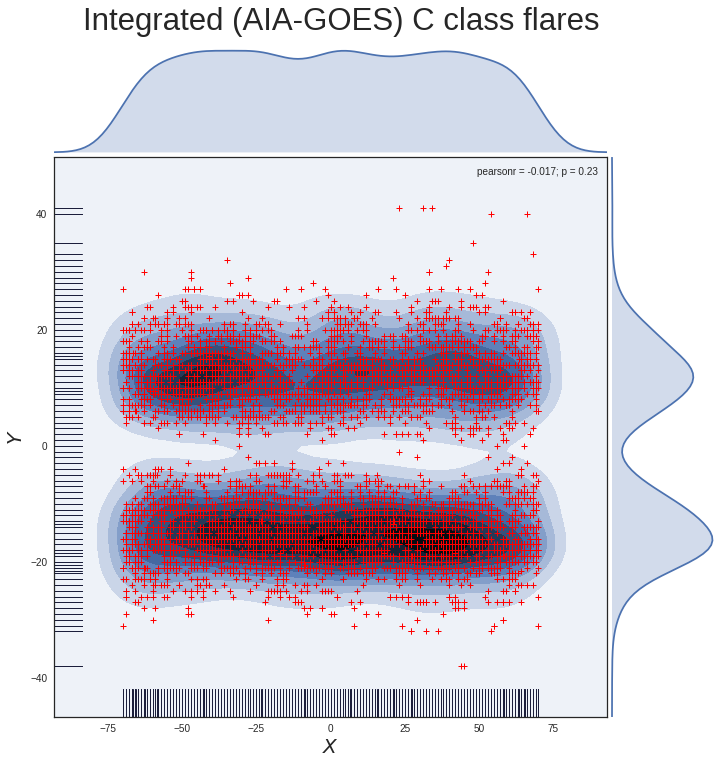

In [45]:
%matplotlib inline

import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(rc={'figure.figsize':(16,12), "font.size":26,"axes.titlesize":26,"axes.labelsize":20})

# datax = all_goes[['event_date', 'peak_time']].groupby('event_date').count()
# sns.countplot(  )
# titanic = sns.load_dataset("titanic")
# titanic
# ax = sns.countplot(x="class", data=titanic)
# 
fdf_c = fdf.copy()

fdf_c['class'] = fdf_c['goes_class'].str[:1] 

print fdf_c[fdf_c['goes_location'] == '(0, 0)'].shape[0]

fdf_c = fdf_c[fdf_c['class'] == 'C']
# fdf_c = fdf_c[fdf_c['goes_location'] != '(0, 0)']




x_loc = pd.to_numeric(fdf_c['fl_lat'])
y_loc = pd.to_numeric(fdf_c['fl_lon'])
# goes_plotter_2011['x_loc'] = x_loc
# goes_plotter_2011['y_loc'] = y_loc
print fdf_c.shape[0]

with sns.axes_style("white"):
#     sns.jointplot(x='x_loc', y='y_loc', data=goes_plotter_2011, kind='kde', color="k");
    g = sns.jointplot(x="fl_lat", y="fl_lon", data=fdf_c, space=0, kind="kde")
    current_palette_4 = sns.color_palette("cubehelix", 7)
    sns.set_palette(current_palette_4)
    
    g.plot_joint(plt.scatter, c="r", s=30, linewidth=1, marker="+")
    g.ax_joint.collections[0].set_alpha(1)
    g.set_axis_labels("$X$", "$Y$");
    g.fig.set_figwidth(12)
    g.fig.set_figheight(12)
    sns.rugplot(x_loc, ax=g.fig.axes[0])
    sns.rugplot(y_loc, vertical=True, ax=g.fig.axes[0]);
    mytitle = "Integrated (AIA-GOES) C class flares" 
    g.fig.suptitle(mytitle)
    
#     g.fig.savefig(mytitle + '.pdf',  bbox_inches='tight', dpi=g.fig.dpi)


6730
164
                     end_time           end_time_x           end_time_y  \
flare_id                                                                  
30        2012-01-17 05:07:00  2012-01-17 05:07:00  2012-01-17 05:07:00   
40        2012-01-18 19:27:00  2012-01-18 19:27:00  2012-01-18 19:27:00   
45        2012-01-19 17:50:00  2012-01-19 17:50:00  2012-01-19 17:50:00   
55        2012-01-23 04:34:00  2012-01-23 03:59:00  2012-01-23 04:34:00   
78        2012-02-06 20:17:00  2012-02-06 20:17:00  2012-02-06 20:17:00   

          event_date goes_class   aia_location goes_location  id_aia  id_goes  \
flare_id                                                                        
30        2012-01-17       M1.0  POINT(-53 18)     (-54, 18)    90.0  12258.0   
40        2012-01-18       M1.7  POINT(-32 17)     (-33, 17)   100.0  12268.0   
45        2012-01-19       M3.2  POINT(-27 32)     (-22, 32)   107.0  12273.0   
55        2012-01-23       M8.7   POINT(21 33)      (21, 28)

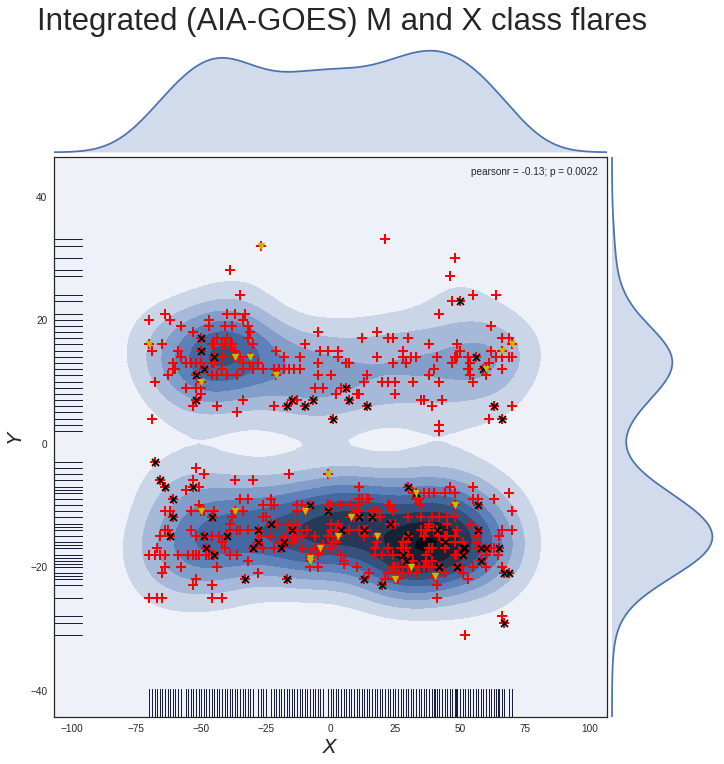

In [124]:
%matplotlib inline

import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(rc={'figure.figsize':(16,12), "font.size":26,"axes.titlesize":26,"axes.labelsize":20})

# datax = all_goes[['event_date', 'peak_time']].groupby('event_date').count()
# sns.countplot(  )
# titanic = sns.load_dataset("titanic")
# titanic
# ax = sns.countplot(x="class", data=titanic)
# 
fdf_c = fdf.copy()

fdf_c['class'] = fdf_c['goes_class'].str[:1] 

print fdf_c[fdf_c['goes_location'] == '(0, 0)'].shape[0]
goes_only_mx = fdf [fdf['id_aia'].isna() & (fdf['goes_class'] >= 'M')]
print goes_only_mx.shape[0]

aia_only_mx = fdf [fdf['id_goes'].isna() & (fdf['goes_class'] >= 'M')]
aia_only_mx.shape[0]

fdf_c = fdf_c[fdf_c['class'] > 'C']
# fdf_c = fdf_c[fdf_c['goes_location'] != '(0, 0)']

print fdf_c.head()


x_loc = pd.to_numeric(fdf_c['fl_lat'])
y_loc = pd.to_numeric(fdf_c['fl_lon'])
# goes_plotter_2011['x_loc'] = x_loc
# goes_plotter_2011['y_loc'] = y_loc
print fdf_c.shape[0]

with sns.axes_style("white"):
#     sns.jointplot(x='x_loc', y='y_loc', data=goes_plotter_2011, kind='kde', color="k");
    g = sns.jointplot(x="fl_lat", y="fl_lon", data=fdf_c, space=0, kind="kde")
    current_palette_4 = sns.color_palette("cubehelix", 7)
    sns.set_palette(current_palette_4)
    
    g.plot_joint(plt.scatter, c="r", s=100, linewidth=2, marker="+")
    g.ax_joint.collections[0].set_alpha(1)
    g.set_axis_labels("$X$", "$Y$");
    g.fig.set_figwidth(12)
    g.fig.set_figheight(12)
    sns.rugplot(x_loc, ax=g.fig.axes[0])
    sns.rugplot(y_loc, vertical=True, ax=g.fig.axes[0]);
    my_ax=g.fig.axes[0]
    
    gox = goes_only_mx['fl_lat']
    goy = goes_only_mx['fl_lon']
    aox = aia_only_mx['fl_lat']
    aoy = aia_only_mx['fl_lon']

    
    my_ax.scatter(gox, goy, c='k', marker="x")
    my_ax.scatter(aox, aoy, c='y', marker="v")
    
    mytitle = "Integrated (AIA-GOES) M and X class flares" 
    g.fig.suptitle(mytitle)
    
#     g.fig.savefig(mytitle + '.pdf',  bbox_inches='tight', dpi=g.fig.dpi)


6730
164
25


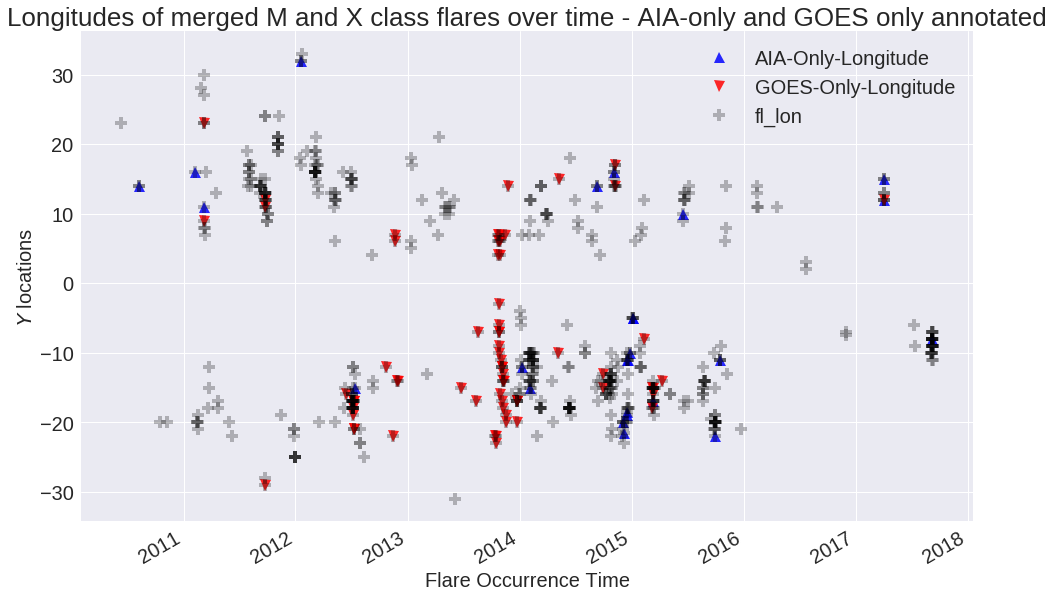

In [94]:


fdf_c = fdf.copy()
fdf_c['Month'] = fdf_c['event_date'].str[5:7] 
fdf_c['Year'] = fdf_c['event_date'].str[:4] 
fdf_c['Year-Month'] = fdf_c[['Year','Month']].apply(lambda x: '-'.join(x), axis=1)
fdf_c.sort_values(['Year-Month'])

fdf_c['class'] = fdf_c['goes_class'].str[:1] 
print fdf_c[fdf_c['goes_location'] == '(0, 0)'].shape[0]

fdf_c = fdf_c[fdf_c['class'] > 'C']

x_loc = pd.to_numeric(fdf_c['fl_lat'])
y_loc = pd.to_numeric(fdf_c['fl_lon'])

goes_only_mx = fdf_c[fdf_c['id_aia'].isna() & (fdf_c['goes_class'] >= 'M')]
print goes_only_mx.shape[0]

aia_only_mx = fdf_c [fdf_c['id_goes'].isna() & (fdf_c['goes_class'] >= 'M')]
print aia_only_mx.shape[0]



plt.rcParams["figure.figsize"] = (16,10)
plt.rcParams.update({'font.size': 20})
plt.rc('xtick', labelsize=20)
plt.rc('ytick', labelsize=20)
params = {'legend.fontsize': 20,
          'legend.handlelength': 2}
plt.rcParams.update(params)
# fig = plt.figure()

aia_only_mx = aia_only_mx.rename(columns={"fl_lon": "AIA-Only-Longitude"})
goes_only_mx = goes_only_mx.rename(columns={"fl_lon": "GOES-Only-Longitude"})
ax = aia_only_mx.plot( x='peak_time', y='AIA-Only-Longitude', style="^", markersize=11, alpha=0.84, c='b')
goes_only_mx.plot( x='peak_time', y='GOES-Only-Longitude', style="v", markersize=11, alpha=0.84, c='r', ax=ax )
fdf_c.plot(x='peak_time', y='fl_lon', style="P", markersize=12, alpha=0.26, c='k', ax = ax)

ax.legend()
ax.set_ylabel("$Y$ locations")
ax.set_xlabel("Flare Occurrence Time")
mytitle = "Longitudes of merged M and X class flares over time - AIA-only and GOES only annotated" 
ax.set_title(mytitle)
fig = ax.get_figure()
fig.savefig(mytitle + '.pdf',  bbox_inches='tight', dpi=fig.dpi)


6730
1892
478


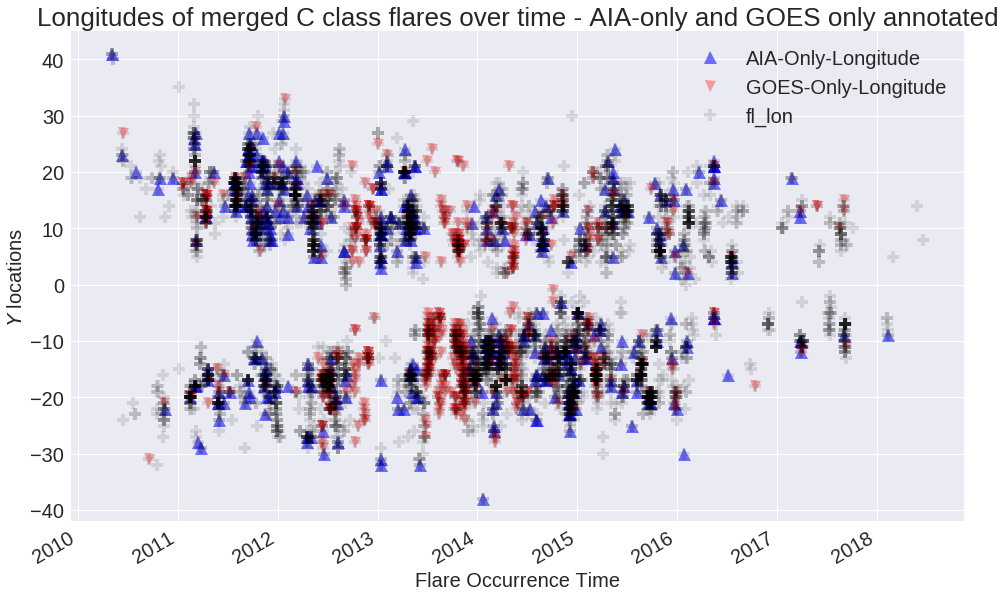

In [105]:


fdf_c = fdf.copy()
fdf_c['Month'] = fdf_c['event_date'].str[5:7] 
fdf_c['Year'] = fdf_c['event_date'].str[:4] 
fdf_c['Year-Month'] = fdf_c[['Year','Month']].apply(lambda x: '-'.join(x), axis=1)
fdf_c.sort_values(['Year-Month'])

fdf_c['class'] = fdf_c['goes_class'].str[:1] 
print fdf_c[fdf_c['goes_location'] == '(0, 0)'].shape[0]

fdf_c = fdf_c[fdf_c['class'] == 'C']

x_loc = pd.to_numeric(fdf_c['fl_lat'])
y_loc = pd.to_numeric(fdf_c['fl_lon'])

goes_only_mx = fdf_c[fdf_c['id_aia'].isna() & (fdf_c['class'] == 'C')]
print goes_only_mx.shape[0]

aia_only_mx = fdf_c [fdf_c['id_goes'].isna() & (fdf_c['class'] == 'C')]
print aia_only_mx.shape[0]



plt.rcParams["figure.figsize"] = (16,10)
plt.rcParams.update({'font.size': 20})
plt.rc('xtick', labelsize=20)
plt.rc('ytick', labelsize=20)
params = {'legend.fontsize': 20,
          'legend.handlelength': 2}
plt.rcParams.update(params)
# fig = plt.figure()

aia_only_mx = aia_only_mx.rename(columns={"fl_lon": "AIA-Only-Longitude"})
goes_only_mx = goes_only_mx.rename(columns={"fl_lon": "GOES-Only-Longitude"})
ax = aia_only_mx.plot( x='peak_time', y='AIA-Only-Longitude', style="^", markersize=13, alpha=0.54, c='b')
goes_only_mx.plot( x='peak_time', y='GOES-Only-Longitude', style="v", markersize=11, alpha=0.34, c='r', ax=ax )
fdf_c.plot(x='peak_time', y='fl_lon', style="P", markersize=12, alpha=0.11, c='k', ax = ax)

ax.legend()
ax.set_ylabel("$Y$ locations")
ax.set_xlabel("Flare Occurrence Time")
mytitle = "Longitudes of merged C class flares over time - AIA-only and GOES only annotated" 
ax.set_title(mytitle)
fig = ax.get_figure()
fig.savefig(mytitle + '.pdf',  bbox_inches='tight', dpi=fig.dpi)


6730
1144
555


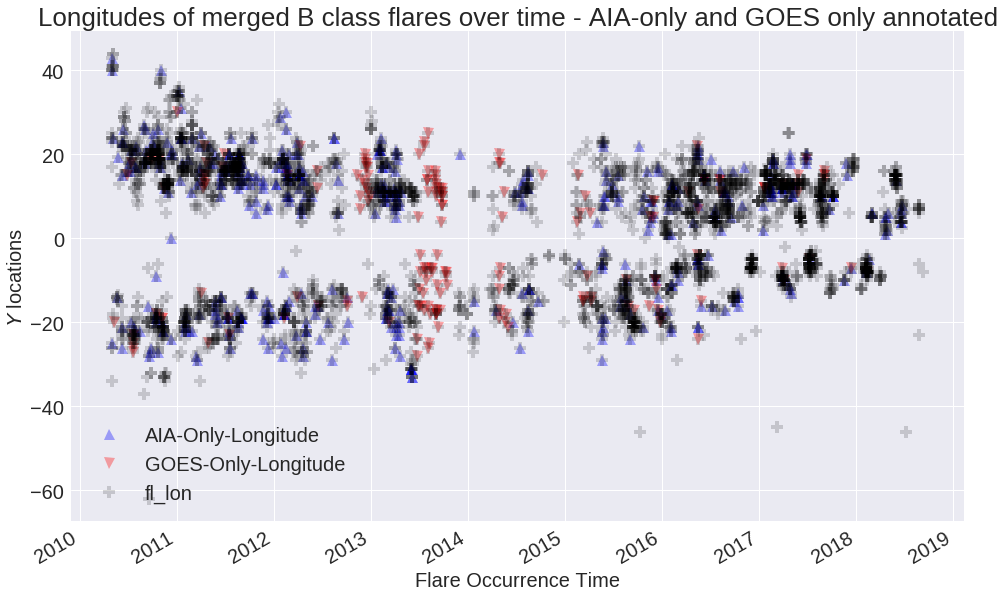

In [117]:


fdf_c = fdf.copy()
fdf_c['Month'] = fdf_c['event_date'].str[5:7] 
fdf_c['Year'] = fdf_c['event_date'].str[:4] 
fdf_c['Year-Month'] = fdf_c[['Year','Month']].apply(lambda x: '-'.join(x), axis=1)
fdf_c.sort_values(['Year-Month'])

fdf_c['class'] = fdf_c['goes_class'].str[:1] 
print fdf_c[fdf_c['goes_location'] == '(0, 0)'].shape[0]

fdf_c = fdf_c[fdf_c['class'] == 'B']

x_loc = pd.to_numeric(fdf_c['fl_lat'])
y_loc = pd.to_numeric(fdf_c['fl_lon'])

goes_only_mx = fdf_c[fdf_c['id_aia'].isna() & (fdf_c['class'] == 'B')]
print goes_only_mx.shape[0]

aia_only_mx = fdf_c [fdf_c['id_goes'].isna() & (fdf_c['class'] == 'B')]
print aia_only_mx.shape[0]



plt.rcParams["figure.figsize"] = (16,10)
plt.rcParams.update({'font.size': 20})
plt.rc('xtick', labelsize=20)
plt.rc('ytick', labelsize=20)
params = {'legend.fontsize': 20,
          'legend.handlelength': 2}
plt.rcParams.update(params)
# fig = plt.figure()

aia_only_mx = aia_only_mx.rename(columns={"fl_lon": "AIA-Only-Longitude"})
goes_only_mx = goes_only_mx.rename(columns={"fl_lon": "GOES-Only-Longitude"})
ax = aia_only_mx.plot( x='peak_time', y='AIA-Only-Longitude', style="^", markersize=11, alpha=0.34, c='b')
goes_only_mx.plot( x='peak_time', y='GOES-Only-Longitude', style="v", markersize=11, alpha=0.34, c='r', ax=ax )
fdf_c.plot(x='peak_time', y='fl_lon', style="P", markersize=12, alpha=0.16, c='k', ax = ax)

ax.legend()
ax.set_ylabel("$Y$ locations")
ax.set_xlabel("Flare Occurrence Time")
mytitle = "Longitudes of merged B class flares over time - AIA-only and GOES only annotated" 
ax.set_title(mytitle)
fig = ax.get_figure()
fig.savefig(mytitle + '.pdf',  bbox_inches='tight', dpi=fig.dpi)


6730
3204
1109
1109


NameError: name 'ylim' is not defined

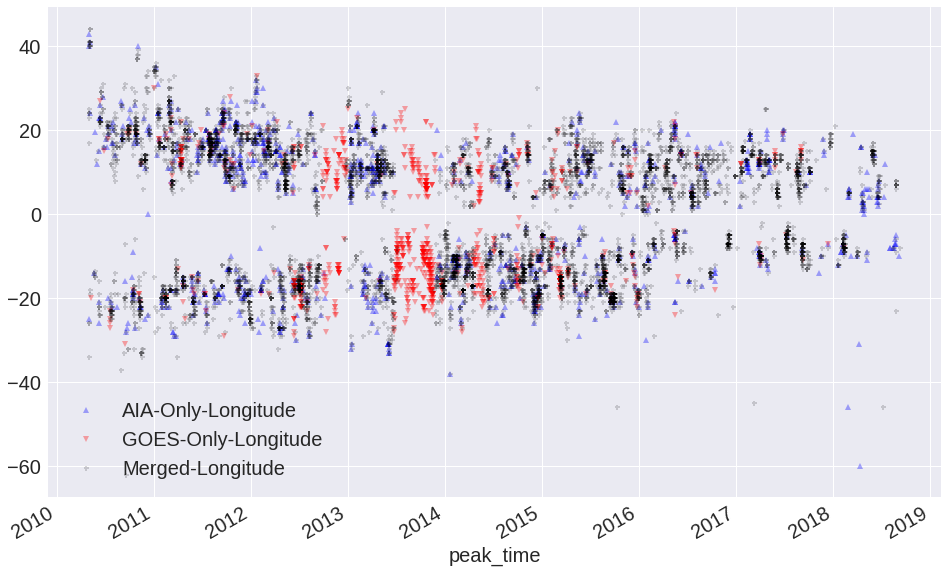

In [125]:


fdf_c = fdf.copy()
fdf_c['Day'] = fdf_c['event_date'].str[8:10] 
fdf_c['Month'] = fdf_c['event_date'].str[5:7] 
fdf_c['Year'] = fdf_c['event_date'].str[:4] 
fdf_c['Year-Month'] = fdf_c[['Year','Month', 'Day']].apply(lambda x: '-'.join(x), axis=1)
fdf_c.sort_values(['Year-Month'])

fdf_c['class'] = fdf_c['goes_class'].str[:1] 
print fdf_c[fdf_c['goes_location'] == '(0, 0)'].shape[0]

# fdf_c = fdf_c[fdf_c['class'] == 'C']

x_loc = pd.to_numeric(fdf_c['fl_lat'])
y_loc = pd.to_numeric(fdf_c['fl_lon'])

goes_only_mx = fdf_c[fdf_c['id_aia'].isna()]
print goes_only_mx.shape[0]

aia_only_mx = fdf_c [fdf_c['id_goes'].isna()]
print aia_only_mx.shape[0]

fdf_c = fdf_c [ (~fdf_c['id_goes'].isna()) & (~fdf_c['id_aia'].isna())]
print aia_only_mx.shape[0]



plt.rcParams["figure.figsize"] = (16,10)
plt.rcParams.update({'font.size': 20})
plt.rc('xtick', labelsize=20)
plt.rc('ytick', labelsize=20)
params = {'legend.fontsize': 20,
          'legend.handlelength': 2}
plt.rcParams.update(params)
# fig = plt.figure()

aia_only_mx = aia_only_mx.rename(columns={"fl_lon": "AIA-Only-Longitude"})
goes_only_mx = goes_only_mx.rename(columns={"fl_lon": "GOES-Only-Longitude"})
fdf_c = fdf_c.rename(columns={"fl_lon": "Merged-Longitude"})

ax = aia_only_mx.plot( x='peak_time', y='AIA-Only-Longitude', style="^", markersize=6, alpha=0.34, c='b')
goes_only_mx.plot( x='peak_time', y='GOES-Only-Longitude', style="v", markersize=6, alpha=0.34, c='r', ax=ax )
fdf_c.plot(x='peak_time', y='Merged-Longitude', style="P", markersize=5, alpha=0.16, c='k', ax = ax)

ax.legend()

ax.set_ylabel("$Y$ locations")
ax.set_xlabel("Flare Occurrence Time")
mytitle = "Longitudes of all merged flares over time - AIA-only and GOES only annotated" 
ax.set_title(mytitle)
fig = ax.get_figure()
fig.savefig(mytitle + '.pdf',  bbox_inches='tight', dpi=fig.dpi)


In [72]:
aia_only_mx

,end_time,end_time_x,end_time_y,event_date,goes_class,aia_location,goes_location,id_aia,id_goes,noaa_active_region_aia,...,peak_time_goes,start_time,noaa_active_region,fl_location,fl_lat,fl_lon,Month,Year,Year-Month,class
flare_id,,,,,,,,,,,,,,,,,,,,,
10847,2012-01-19 16:30:00,NaN,NaN,2012-01-19,M2.6,POINT(-27 32),NaN,106.0,NaN,11402.0,...,NaT,2012-01-19 13:43:00,11402.0,POINT(-27 32),-27.0,32.0,01,2012,2012-01,M
10956,2012-07-14 05:07:00,NaN,NaN,2012-07-14,M1.0,POINT(18 -15),NaN,1183.0,NaN,11520.0,...,NaT,2012-07-14 03:32:00,11520.0,POINT(18 -15),18.0,-15.0,07,2012,2012-07,M
11199,2015-01-04 15:36:00,NaN,NaN,2015-01-04,M1.3,POINT(-1 -5),NaN,3436.0,NaN,12253.0,...,NaT,2015-01-04 15:18:00,12253.0,POINT(-1 -5),-1.0,-5.0,01,2015,2015-01,M
11200,2015-01-04 15:53:00,NaN,NaN,2015-01-04,M1.3,POINT(-1 -5),NaN,3437.0,NaN,12253.0,...,NaT,2015-01-04 15:18:00,12253.0,POINT(-1 -5),-1.0,-5.0,01,2015,2015-01,M
11210,2015-03-13 04:16:00,NaN,NaN,2015-03-13,M1.2,POINT(-4 -17),NaN,3743.0,NaN,12297.0,...,NaT,2015-03-13 03:47:00,12297.0,POINT(-4 -17),-4.0,-17.0,03,2015,2015-03,M
11249,2015-06-18 19:00:00,NaN,NaN,2015-06-18,M3.1,POINT(-50 10),NaN,4317.0,NaN,12371.0,...,NaT,2015-06-18 16:25:00,12371.0,POINT(-50 10),-50.0,10.0,06,2015,2015-06,M
11280,2015-09-28 13:29:00,NaN,NaN,2015-09-28,M1.1,POINT(25 -22),NaN,4863.0,NaN,12422.0,...,NaT,2015-09-28 13:01:00,12422.0,POINT(25 -22),25.0,-22.0,09,2015,2015-09,M
11283,2015-10-15 23:37:00,NaN,NaN,2015-10-15,M1.1,POINT(-50 -11),NaN,4991.0,NaN,12434.0,...,NaT,2015-10-15 22:45:00,12434.0,POINT(-50 -11),-50.0,-11.0,10,2015,2015-10,M
11357,2017-04-02 08:45:00,NaN,NaN,2017-04-02,M5.4,POINT(60 12),NaN,5646.0,NaN,12644.0,...,NaT,2017-04-02 07:50:00,12644.0,POINT(60 12),60.0,12.0,04,2017,2017-04,M
